In [33]:
import sys
from pathlib import Path

project_src = str(Path("..").resolve() / "src")
if project_src not in sys.path:
    sys.path.insert(0, project_src)

for module_name in list(sys.modules):
    if module_name == "pysse" or module_name.startswith("pysse."):
        del sys.modules[module_name]

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from pysse import ElectricFieldPulse, SSE, SpectrumUtils, Theory

In [34]:
mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.serif": ["DejaVu Serif"],
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

In [35]:
from pysse import SpectrumUtils

fft_pulse = SpectrumUtils.fft_pulse

In [36]:
intensity = 1E4  # Intensity in W/cm^2
fwhm = 800  # FWHM in as
omega_x = 277  # Pulse oscillation frequency in eV
omega_o = 8.13947
dt = 5E-3  # Finer time step for smoother TDSE propagation

field_x = ElectricFieldPulse(intensity=intensity, dt=dt, pulse_type='gaussian_sin', fwhm=fwhm, omega_sin=omega_x, time_span=800)
field_o = ElectricFieldPulse(intensity=intensity, dt=dt, pulse_type='gaussian_sin', fwhm=fwhm, omega_sin=omega_o, time_span=800)

In [37]:
print(field_x)
print(field_o)

Electric Field Pulse:
  Intensity: 10000.0 W/cm^2
  FWHM: 800 as
  Central frequency: 10.179557097393005 a.u.
  E_max: 5.337605126836238e-07 a.u.
  Sigma: 14.044851851434963 a.u.
  Time step (dt): 0.005 a.u.
  Number of steps: 160000
  Pulse type: gaussian_sin
  Time at maximum: 71.0 a.u.
  Energy window: None a.u.
  Pulse width: None a.u.

Electric Field Pulse:
  Intensity: 10000.0 W/cm^2
  FWHM: 800 as
  Central frequency: 0.2991198541787633 a.u.
  E_max: 5.337605126836238e-07 a.u.
  Sigma: 14.044851851434963 a.u.
  Time step (dt): 0.005 a.u.
  Number of steps: 160000
  Pulse type: gaussian_sin
  Time at maximum: 71.0 a.u.
  Energy window: None a.u.
  Pulse width: None a.u.



In [38]:
propagation_method = "RK4"

Text(0.5, 1.0, 'FFT of Sinusoidal Gaussian Pulse X-rays')

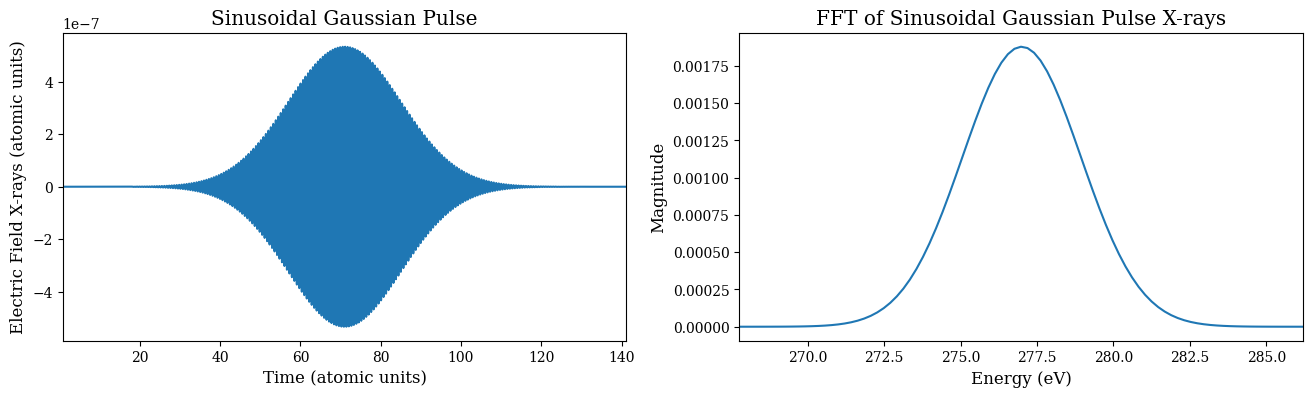

In [39]:
plt.figure(figsize=(16,4))

plt.subplot(1,2,1)
plt.plot(field_x.time, field_x.pulse, label='Carbon')
plt.xlabel('Time (atomic units)')
plt.ylabel('Electric Field X-rays (atomic units)')
plt.xlim(field_x.time_limits)
plt.title('Sinusoidal Gaussian Pulse')

plt.subplot(1,2,2)
plt.plot(field_x.freq, field_x.magnitude)
plt.xlim(field_x.freq_limits)
plt.xlabel('Energy (eV)')
plt.ylabel('Magnitude')
plt.title('FFT of Sinusoidal Gaussian Pulse X-rays')

Text(0.5, 1.0, 'FFT of Sinusoidal Gaussian Pulse Optical')

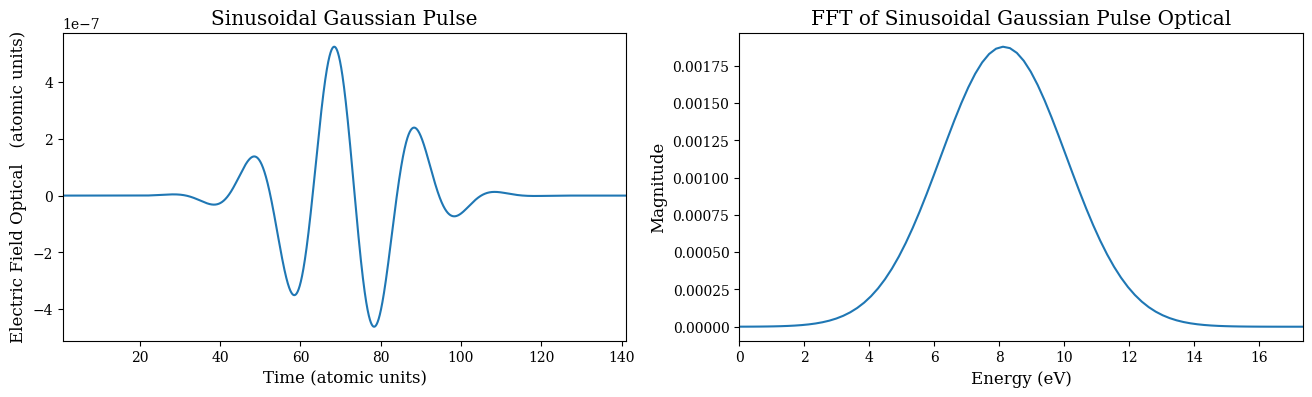

In [40]:
plt.figure(figsize=(16,4))

plt.subplot(1,2,1)
plt.plot(field_o.time, field_o.pulse, label='Carbon')
plt.xlabel('Time (atomic units)')
plt.ylabel('Electric Field Optical   (atomic units)')
plt.xlim(field_o.time_limits)
plt.title('Sinusoidal Gaussian Pulse')

plt.subplot(1,2,2)
plt.plot(field_o.freq, field_o.magnitude)
plt.xlim(field_o.freq_limits)
plt.xlabel('Energy (eV)')
plt.ylabel('Magnitude')
plt.title('FFT of Sinusoidal Gaussian Pulse Optical')

In [41]:
initial_conditions = np.array([
    [0,1.0]
])

In [42]:
# --- Analytic SFG theory (class_theory.py) ---

data_path = "../data_minimal/dummy_data/"
n_roots_valence = 1   # Root 1 in ci_energy.inp
n_roots_core = 2      # Root 2 in ci_energy.inp

gammas = {
    "gamma_cg": 0.1,   # eV
    "gamma_eg": 0.1,   # eV
    "gamma_cpg": 0.1,  # eV
    "gamma_ce": 0.1,  # eV
}

_, field_x_fft = SpectrumUtils.fft_pulse(field_x.time, field_x.pulse)
_, field_o_fft = SpectrumUtils.fft_pulse(field_o.time, field_o.pulse)


field_x_fft[field_x.freq < 0] = 0
field_o_fft[field_x.freq < 0] = 0

theory_fields = {
    "freqs": field_x.freq,
    "field_x": field_x_fft,
    "field_o": field_o_fft,
}

theory = Theory(
    data_path,
    theory_fields,
    n_roots_valence=n_roots_valence,
    n_roots_core=n_roots_core,
    gammas=gammas,
)

sfg_theory = theory.sfg_signal
dfg_theory = theory.dfg_signal
theory_freqs = theory.freqs
theory_mask = theory_freqs > 0

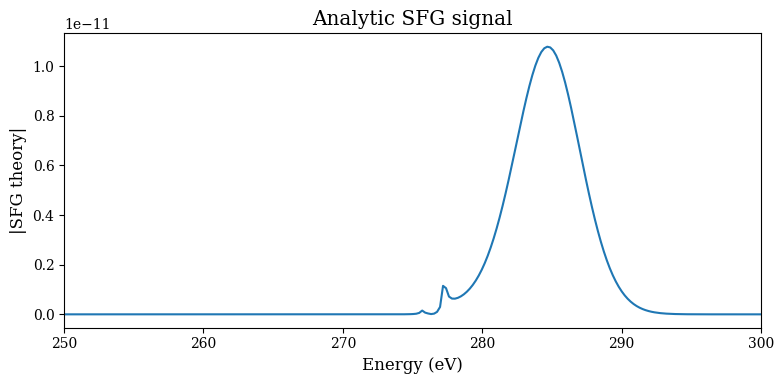

In [43]:
plt.figure(figsize=(8, 4))
plt.plot(theory_freqs, np.abs(sfg_theory))
plt.xlim(250, 300)
plt.xlabel("Energy (eV)")
plt.ylabel("|SFG theory|")
plt.title("Analytic SFG signal")
plt.tight_layout()
plt.show()

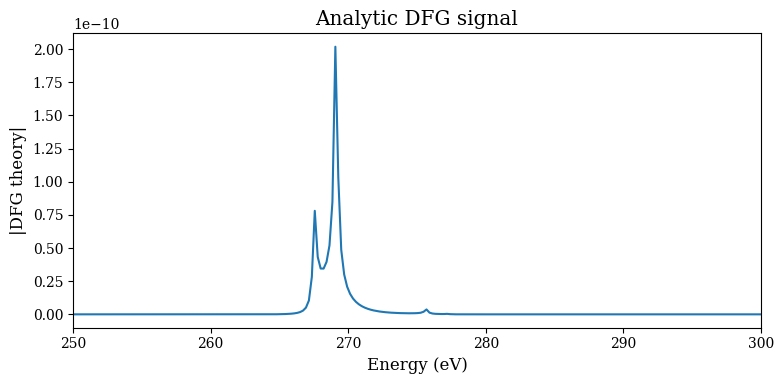

In [44]:
plt.figure(figsize=(8, 4))
plt.plot(theory_freqs, np.abs(dfg_theory))
plt.xlim(250, 300)
plt.xlabel("Energy (eV)")
plt.ylabel("|DFG theory|")
plt.title("Analytic DFG signal")
plt.tight_layout()
plt.show()

In [45]:
from pysse import fill_stokes_grid

lambda_val = 1E-3
lambda_configs = {
    "lambda_pp": (lambda_val, lambda_val),
    "lambda_pm": (lambda_val, -lambda_val),
    "lambda_mp": (-lambda_val, lambda_val),
    "lambda_mm": (-lambda_val, -lambda_val),
}
N1 = 3
N2 = 3
time_span = 800
n_time = int(time_span / dt)

P_1_1 = np.zeros((N1, N2, 3, n_time), dtype=np.complex128)
time_axis = np.linspace(0, n_time * dt, n_time)

fill_stokes_grid(
    P_1_1,
    n1=N1,
    n2=N2,
    filepath="../data_minimal/dummy_data/",
    intensity=intensity,
    dt=dt,
    fwhm=fwhm,
    omega_x=omega_x,
    omega_o=omega_o,
    time_span=time_span,
    lambda_val=lambda_val,
    lambda_configs=lambda_configs,
    initial_conditions=initial_conditions,
    propagation_method=propagation_method,
    n_jobs=-1,
    src_path=project_src,
)

FT_P_1_1_t = np.fft.fftshift(np.fft.fft2(P_1_1, axes=(0, 1)), axes=(0, 1))
freqs, FT_P_1_1 = SpectrumUtils.fft_pulse_axis(time_axis, FT_P_1_1_t, axis=-1)


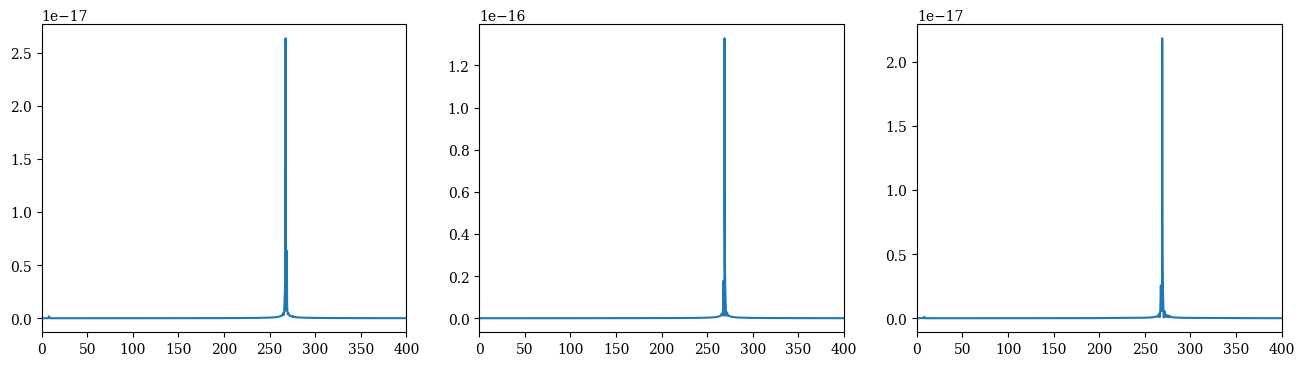

In [46]:
sign_opt, sign_x = 0,2  #SFG: 2,2, DFG: 0,2

signal_x = FT_P_1_1[sign_opt, sign_x, 0, :]
signal_y = FT_P_1_1[sign_opt, sign_x, 1, :]
signal_z = FT_P_1_1[sign_opt, sign_x, 2, :]

mask = freqs > 0

signal_x_mask = signal_x[mask]
signal_y_mask = signal_y[mask]
signal_z_mask = signal_z[mask]
freqs_mask = freqs[mask]


plt.figure(figsize=(16,4))

plt.subplot(1,3,1)
plt.plot(freqs_mask, np.abs(signal_x_mask))
plt.xlim(0, 400)
plt.subplot(1,3,2)
plt.plot(freqs_mask, np.abs(signal_y_mask))
plt.xlim(0, 400)
plt.subplot(1,3,3)
plt.plot(freqs_mask, np.abs(signal_z_mask))
plt.xlim(0, 400)
plt.show()



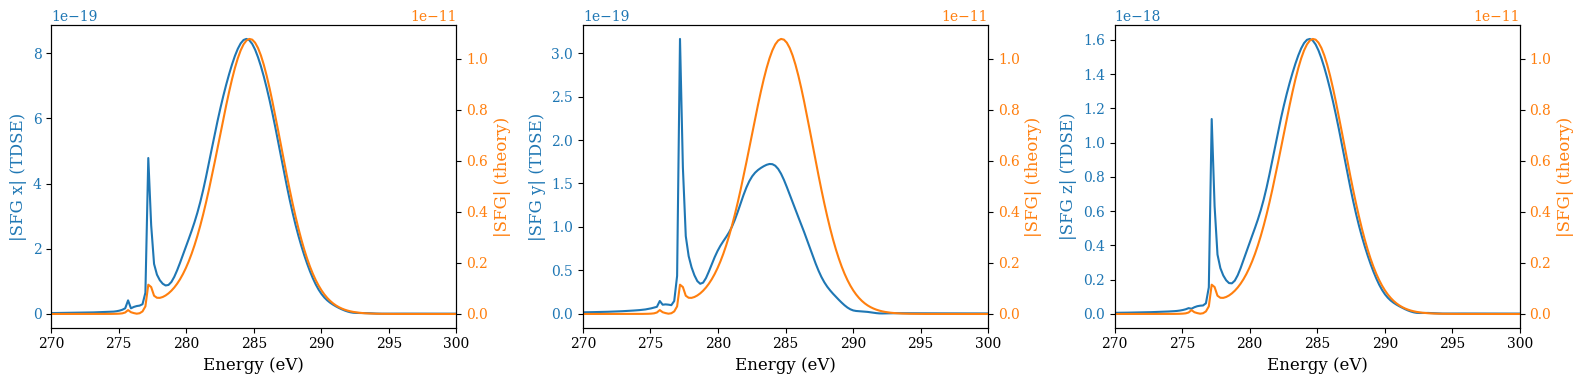

In [47]:
sfg_index_opt, sfg_index_x = 2, 2

sfg_signal_x = FT_P_1_1[sfg_index_opt, sfg_index_x, 0, :]
sfg_signal_y = FT_P_1_1[sfg_index_opt, sfg_index_x, 1, :]
sfg_signal_z = FT_P_1_1[sfg_index_opt, sfg_index_x, 2, :]

sfg_signal_x_mask = sfg_signal_x[mask]
sfg_signal_y_mask = sfg_signal_y[mask]
sfg_signal_z_mask = sfg_signal_z[mask]

theory_freqs_mask = theory_freqs[theory_mask]
theory_signal_mask = np.abs(sfg_theory[theory_mask])

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

for ax, sim_signal, label in zip(
    axes,
    [sfg_signal_x_mask, sfg_signal_y_mask, sfg_signal_z_mask],
    ["x", "y", "z"],
):
    ax.plot(freqs_mask, np.abs(sim_signal), color="C0", label="TDSE")
    ax.set_xlim(270, 300)
    ax.set_xlabel("Energy (eV)")
    ax.set_ylabel(f"|SFG {label}| (TDSE)", color="C0")
    ax.tick_params(axis="y", labelcolor="C0")

    ax_theory = ax.twinx()
    ax_theory.plot(
        theory_freqs_mask,
        theory_signal_mask,
        color="C1",
        label="Theory",
    )
    ax_theory.set_ylabel("|SFG| (theory)", color="C1")
    ax_theory.tick_params(axis="y", labelcolor="C1")

plt.tight_layout()
plt.show()

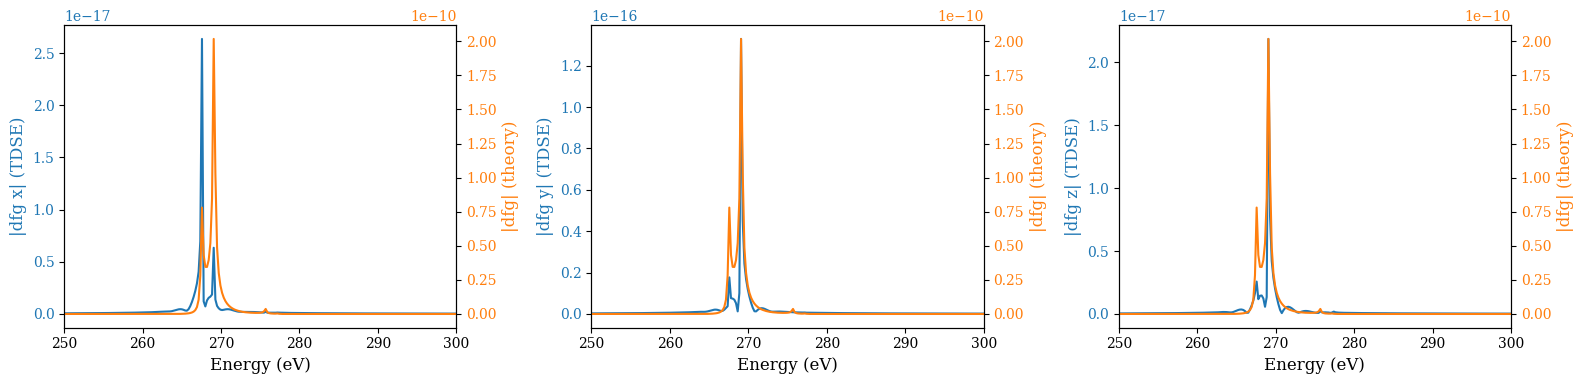

In [48]:
dfg_index_opt, dfg_index_x = 0, 2

dfg_signal_x = FT_P_1_1[dfg_index_opt, dfg_index_x, 0, :]
dfg_signal_y = FT_P_1_1[dfg_index_opt, dfg_index_x, 1, :]
dfg_signal_z = FT_P_1_1[dfg_index_opt, dfg_index_x, 2, :]

dfg_signal_x_mask = dfg_signal_x[mask]
dfg_signal_y_mask = dfg_signal_y[mask]
dfg_signal_z_mask = dfg_signal_z[mask]

theory_freqs_mask = theory_freqs[theory_mask]
theory_signal_mask = np.abs(dfg_theory[theory_mask])

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharex=True)

for ax, sim_signal, label in zip(
    axes,
    [dfg_signal_x_mask, dfg_signal_y_mask, dfg_signal_z_mask],
    ["x", "y", "z"],
):
    ax.plot(freqs_mask, np.abs(sim_signal), color="C0", label="TDSE")
    ax.set_xlim(250, 300)
    ax.set_xlabel("Energy (eV)")
    ax.set_ylabel(f"|dfg {label}| (TDSE)", color="C0")
    ax.tick_params(axis="y", labelcolor="C0")

    ax_theory = ax.twinx()
    ax_theory.plot(
        theory_freqs_mask,
        theory_signal_mask,
        color="C1",
        label="Theory",
    )
    ax_theory.set_ylabel("|dfg| (theory)", color="C1")
    ax_theory.tick_params(axis="y", labelcolor="C1")

plt.tight_layout()
plt.show()